# Notebook 04: Target Engineering

## Objective

The ASSISTments dataset contains detailed student interaction records but does not explicitly identify whether a student has forgotten a previously learned skill. Therefore, the primary objective of this notebook is to engineer a scientifically valid target variable (`forget_event`) by analyzing future Student–Skill interaction sequences.

## Methodology

This notebook constructs the target variable using ordered interaction histories. Instead of relying on manually assigned labels, the target will be derived from the learner's future performance on the same skill.

## Expected Output

At the end of this notebook, a new dataset containing the engineered target variable will be generated and saved for feature engineering and predictive modeling.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Import Required Libraries

### Objective

Import all necessary libraries required for data loading, preprocessing, and target engineering.

### Methodology

The project directory is automatically detected from Google Drive so that every team member can execute the notebook without changing file paths.

### Expected Output

Project configuration is successfully loaded and the project root directory is displayed.

In [ ]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np

PROJECT_NAME = "Personal Knowledge Decay Predictor"

matches = [
    p for p in Path("/content/drive/MyDrive").rglob(PROJECT_NAME)
    if p.is_dir()
]

PROJECT_ROOT = matches[0]

sys.path.append(str(PROJECT_ROOT))

from config import *

print("✅ Project Root :", PROJECT_ROOT)

✅ Project Root : /content/drive/MyDrive/Personal Knowledge Decay Predictor


## Load the Sequence Dataset

### Objective

Load the processed interaction sequence dataset created in Notebook 03.

### Methodology

The dataset contains chronologically ordered Student–Skill interactions that will be used to engineer the forgetting target.

### Expected Output

The sequence dataset is successfully loaded into memory.

In [ ]:
df = pd.read_csv(
    f"{DATA_DIR}/Processed/sequence_ready_dataset.csv",
    low_memory=False
)

print("Dataset Shape :", df.shape)

df.head()

Dataset Shape : (942816, 78)


,studentId,SY ASSISTments Usage,AveKnow,AveCarelessness,AveCorrect,NumActions,AveResBored,AveResEngcon,AveResConf,AveResFrust,...,RES_BORED,RES_CONCENTRATING,RES_CONFUSED,RES_FRUSTRATED,RES_OFFTASK,RES_GAMING,Ln-1,Ln,MCAS,interaction_order
0,8,2004-2005,0.352417,0.183276,0.483901,1056,0.208389,0.679126,0.115905,0.112408,...,0.156027,0.719044,0.000000,0.009561,0.122595,0.005797,0.497,0.759192485,45,1
1,8,2004-2005,0.352417,0.183276,0.483901,1056,0.208389,0.679126,0.115905,0.112408,...,0.505313,0.554432,0.000000,0.009561,0.889219,0.005797,0.759192485,0.908767782,45,2
2,8,2004-2005,0.352417,0.183276,0.483901,1056,0.208389,0.679126,0.115905,0.112408,...,0.156027,0.719044,0.000000,0.009561,0.122595,0.005797,0.908767782,0.969112157,45,3
3,8,2004-2005,0.352417,0.183276,0.483901,1056,0.208389,0.679126,0.115905,0.112408,...,0.156027,0.719044,0.000000,0.009561,0.122595,0.005797,0.969112157,0.989972799,45,4
4,8,2004-2005,0.352417,0.183276,0.483901,1056,0.208389,0.679126,0.115905,0.112408,...,0.376427,0.448273,0.060808,0.000000,0.440265,0.010665,0.989972799,0.936555224,45,5


## Dataset Overview

### Objective

Understand the overall structure of the dataset before beginning target engineering.

### Methodology

Inspect the dataset dimensions, column names, data types, and sample records.

### Expected Output

A clear understanding of the available variables and their data types.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 942816 entries, 0 to 942815
Data columns (total 78 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   studentId                               942816 non-null  int64  
 1   SY ASSISTments Usage                    942816 non-null  object 
 2   AveKnow                                 942816 non-null  float64
 3   AveCarelessness                         942816 non-null  float64
 4   AveCorrect                              942816 non-null  float64
 5   NumActions                              942816 non-null  int64  
 6   AveResBored                             942816 non-null  float64
 7   AveResEngcon                            942816 non-null  float64
 8   AveResConf                              942816 non-null  float64
 9   AveResFrust                             942816 non-null  float64
 10  AveResOfftask                           9428

In [ ]:
df.head()

,studentId,SY ASSISTments Usage,AveKnow,AveCarelessness,AveCorrect,NumActions,AveResBored,AveResEngcon,AveResConf,AveResFrust,...,RES_BORED,RES_CONCENTRATING,RES_CONFUSED,RES_FRUSTRATED,RES_OFFTASK,RES_GAMING,Ln-1,Ln,MCAS,interaction_order
0,8,2004-2005,0.352417,0.183276,0.483901,1056,0.208389,0.679126,0.115905,0.112408,...,0.156027,0.719044,0.000000,0.009561,0.122595,0.005797,0.497,0.759192485,45,1
1,8,2004-2005,0.352417,0.183276,0.483901,1056,0.208389,0.679126,0.115905,0.112408,...,0.505313,0.554432,0.000000,0.009561,0.889219,0.005797,0.759192485,0.908767782,45,2
2,8,2004-2005,0.352417,0.183276,0.483901,1056,0.208389,0.679126,0.115905,0.112408,...,0.156027,0.719044,0.000000,0.009561,0.122595,0.005797,0.908767782,0.969112157,45,3
3,8,2004-2005,0.352417,0.183276,0.483901,1056,0.208389,0.679126,0.115905,0.112408,...,0.156027,0.719044,0.000000,0.009561,0.122595,0.005797,0.969112157,0.989972799,45,4
4,8,2004-2005,0.352417,0.183276,0.483901,1056,0.208389,0.679126,0.115905,0.112408,...,0.376427,0.448273,0.060808,0.000000,0.440265,0.010665,0.989972799,0.936555224,45,5


In [ ]:
df.tail()

,studentId,SY ASSISTments Usage,AveKnow,AveCarelessness,AveCorrect,NumActions,AveResBored,AveResEngcon,AveResConf,AveResFrust,...,RES_BORED,RES_CONCENTRATING,RES_CONFUSED,RES_FRUSTRATED,RES_OFFTASK,RES_GAMING,Ln-1,Ln,MCAS,interaction_order
942811,7783,2005-2006,0.210902,0.094888,0.456522,276,0.271812,0.611678,0.123615,0.137851,...,0.376427,0.511752,0.060808,0.000000,0.122595,0.005797,0.024,0.103132687,28,1
942812,7783,2005-2006,0.210902,0.094888,0.456522,276,0.271812,0.611678,0.123615,0.137851,...,0.505313,0.659331,0.000000,0.000000,0.889219,0.001483,0.103132687,0.114464435,28,2
942813,7783,2005-2006,0.210902,0.094888,0.456522,276,0.271812,0.611678,0.123615,0.137851,...,0.156027,0.722702,0.000000,0.000000,0.122595,0.101184,0.103132687,0.114464435,28,3
942814,7783,2005-2006,0.210902,0.094888,0.456522,276,0.271812,0.611678,0.123615,0.137851,...,0.156027,0.722702,0.000000,0.000000,0.122595,0.101184,0.103132687,0.114464435,28,4
942815,7783,2005-2006,0.210902,0.094888,0.456522,276,0.271812,0.611678,0.123615,0.137851,...,0.156027,0.891616,0.000000,0.009561,0.122595,0.002815,0.114464435,0.353921993,28,5


## Missing Value Verification

### Objective

Verify that the cleaned dataset contains no unexpected missing values before target engineering.

### Methodology

Compute the number of missing values in every feature and identify any remaining incomplete records.

### Expected Output

Confirmation that the dataset is ready for target engineering.

In [ ]:
missing = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

missing = missing[missing > 0]

display(missing)

,0


## Feature Inventory

### Objective

Review every available feature before engineering the target variable.

### Methodology

Generate a complete list of dataset columns. This helps identify candidate features for modeling and detect variables that could introduce data leakage.

### Expected Output

A complete inventory of all available features.

In [ ]:
feature_inventory = pd.DataFrame({
    "Feature Name": df.columns
})

display(feature_inventory)

,Feature Name
0,studentId
1,SY ASSISTments Usage
2,AveKnow
3,AveCarelessness
4,AveCorrect
...,...
73,RES_GAMING
74,Ln-1
75,Ln
76,MCAS


# Target Engineering Strategy

## Objective

Before constructing the target variable, it is necessary to define what constitutes a knowledge forgetting event.

## Methodology

Unlike traditional educational datasets, the ASSISTments dataset does not explicitly label whether a learner has forgotten a skill. Therefore, the forgetting event must be inferred from future Student–Skill interactions.

The target variable will be engineered by analyzing the learner's future performance on the same skill rather than relying on manually assigned labels.

## Expected Output

A scientifically justified definition of the `forget_event` target variable.

# Target Variable Definition

## Objective

Define a scientifically valid target variable (`forget_event`) that represents knowledge decay using future Student–Skill interaction sequences.

## Methodology

A student is considered to have experienced a forgetting event only when there is sufficient evidence that the skill was previously learned and later performed incorrectly during a future interaction.

The target variable is therefore engineered from the interaction history rather than being manually assigned.

## Expected Output

A clear and reproducible definition of the `forget_event` target variable.

## Sequence Validation

### Objective

Verify that every Student–Skill interaction sequence is correctly ordered before constructing the target variable.

### Methodology

The dataset should already contain an interaction order created in Notebook 03. This section verifies that the ordering is consistent.

### Expected Output

Confirmation that every Student–Skill sequence is ordered correctly.

In [ ]:
df = df.sort_values(
    ["studentId", "skill", "interaction_order"]
).reset_index(drop=True)

df.head()

,studentId,SY ASSISTments Usage,AveKnow,AveCarelessness,AveCorrect,NumActions,AveResBored,AveResEngcon,AveResConf,AveResFrust,...,RES_BORED,RES_CONCENTRATING,RES_CONFUSED,RES_FRUSTRATED,RES_OFFTASK,RES_GAMING,Ln-1,Ln,MCAS,interaction_order
0,8,2004-2005,0.352417,0.183276,0.483901,1056,0.208389,0.679126,0.115905,0.112408,...,0.156027,0.719044,0.000000,0.009561,0.122595,0.005797,0.497,0.759192485,45,1
1,8,2004-2005,0.352417,0.183276,0.483901,1056,0.208389,0.679126,0.115905,0.112408,...,0.505313,0.554432,0.000000,0.009561,0.889219,0.005797,0.759192485,0.908767782,45,2
2,8,2004-2005,0.352417,0.183276,0.483901,1056,0.208389,0.679126,0.115905,0.112408,...,0.156027,0.719044,0.000000,0.009561,0.122595,0.005797,0.908767782,0.969112157,45,3
3,8,2004-2005,0.352417,0.183276,0.483901,1056,0.208389,0.679126,0.115905,0.112408,...,0.156027,0.719044,0.000000,0.009561,0.122595,0.005797,0.969112157,0.989972799,45,4
4,8,2004-2005,0.352417,0.183276,0.483901,1056,0.208389,0.679126,0.115905,0.112408,...,0.376427,0.448273,0.060808,0.000000,0.440265,0.010665,0.989972799,0.936555224,45,5


## Construct Future Interactions

### Objective

Create helper variables describing the student's next interaction on the same skill.

### Methodology

For every Student–Skill sequence, the next interaction is identified using chronological order. These helper variables will later be used to engineer the forgetting target.

### Expected Output

Temporary variables describing future performance.

In [ ]:
df["next_correct"] = (
    df.groupby(["studentId", "skill"])["correct"]
      .shift(-1)
)

df["next_interaction_order"] = (
    df.groupby(["studentId", "skill"])["interaction_order"]
      .shift(-1)
)

In [ ]:
df[
    [
        "studentId",
        "skill",
        "interaction_order",
        "correct",
        "next_correct"
    ]
].head(15)

,studentId,skill,interaction_order,correct,next_correct
0,8,addition,1,1,1.0
1,8,addition,2,1,1.0
2,8,addition,3,1,1.0
3,8,addition,4,1,0.0
4,8,addition,5,0,1.0
5,8,addition,6,1,1.0
6,8,addition,7,1,1.0
7,8,addition,8,1,1.0
8,8,addition,9,1,1.0
9,8,addition,10,1,1.0


In [ ]:
print(df.columns.tolist())

['studentId', 'SY ASSISTments Usage', 'AveKnow', 'AveCarelessness', 'AveCorrect', 'NumActions', 'AveResBored', 'AveResEngcon', 'AveResConf', 'AveResFrust', 'AveResOfftask', 'AveResGaming', 'action_num', 'skill', 'problemId', 'problemType', 'assignmentId', 'assistmentId', 'startTime', 'endTime', 'timeTaken', 'correct', 'original', 'hint', 'hintCount', 'hintTotal', 'scaffold', 'bottomHint', 'attemptCount', 'frIsHelpRequest', 'frPast5HelpRequest', 'frPast8HelpRequest', 'stlHintUsed', 'past8BottomOut', 'totalFrPercentPastWrong', 'totalFrPastWrongCount', 'frPast5WrongCount', 'frPast8WrongCount', 'totalFrTimeOnSkill', 'timeSinceSkill', 'frWorkingInSchool', 'totalFrAttempted', 'totalFrSkillOpportunities', 'responseIsFillIn', 'responseIsChosen', 'endsWithScaffolding', 'endsWithAutoScaffolding', 'frTimeTakenOnScaffolding', 'frTotalSkillOpportunitiesScaffolding', 'totalFrSkillOpportunitiesByScaffolding', 'frIsHelpRequestScaffolding', 'timeGreater5Secprev2wrong', 'sumRight', 'helpAccessUnder2Sec'

## Remove Existing Helper Columns

### Objective

Ensure that target engineering starts from a clean dataset by removing any helper columns created during previous experiments.

### Methodology

If helper columns related to future interactions already exist, they are removed before constructing new target variables.

### Expected Output

A clean dataset ready for reproducible target engineering.

In [ ]:
helper_columns = [
    "next_correct",
    "next_interaction_order",
    "future_accuracy",
    "forget_event"
]

df = df.drop(columns=helper_columns, errors="ignore")

print("Existing helper columns removed (if present).")

Existing helper columns removed (if present).


## Sort Student–Skill Sequences

### Objective

Ensure that every interaction sequence follows the correct chronological order.

### Methodology

Interactions are sorted using Student ID, Skill, and Interaction Order.

### Expected Output

Chronologically ordered Student–Skill sequences.

In [ ]:
df = (
    df.sort_values(
        ["studentId", "skill", "interaction_order"]
    )
    .reset_index(drop=True)
)

df.head()

,studentId,SY ASSISTments Usage,AveKnow,AveCarelessness,AveCorrect,NumActions,AveResBored,AveResEngcon,AveResConf,AveResFrust,...,RES_BORED,RES_CONCENTRATING,RES_CONFUSED,RES_FRUSTRATED,RES_OFFTASK,RES_GAMING,Ln-1,Ln,MCAS,interaction_order
0,8,2004-2005,0.352417,0.183276,0.483901,1056,0.208389,0.679126,0.115905,0.112408,...,0.156027,0.719044,0.000000,0.009561,0.122595,0.005797,0.497,0.759192485,45,1
1,8,2004-2005,0.352417,0.183276,0.483901,1056,0.208389,0.679126,0.115905,0.112408,...,0.505313,0.554432,0.000000,0.009561,0.889219,0.005797,0.759192485,0.908767782,45,2
2,8,2004-2005,0.352417,0.183276,0.483901,1056,0.208389,0.679126,0.115905,0.112408,...,0.156027,0.719044,0.000000,0.009561,0.122595,0.005797,0.908767782,0.969112157,45,3
3,8,2004-2005,0.352417,0.183276,0.483901,1056,0.208389,0.679126,0.115905,0.112408,...,0.156027,0.719044,0.000000,0.009561,0.122595,0.005797,0.969112157,0.989972799,45,4
4,8,2004-2005,0.352417,0.183276,0.483901,1056,0.208389,0.679126,0.115905,0.112408,...,0.376427,0.448273,0.060808,0.000000,0.440265,0.010665,0.989972799,0.936555224,45,5


## Verify Interaction Sequences

### Objective

Validate that the ordering of interactions is correct before constructing the target.

### Methodology

Display sample Student–Skill interaction histories to confirm chronological ordering.

### Expected Output

Correctly ordered interaction sequences.

In [ ]:
sample_student = df["studentId"].iloc[0]
sample_skill = df["skill"].iloc[0]

sample_sequence = df[
    (df["studentId"] == sample_student) &
    (df["skill"] == sample_skill)
][
    [
        "studentId",
        "skill",
        "interaction_order",
        "correct"
    ]
]

sample_sequence

,studentId,skill,interaction_order,correct
0,8,addition,1,1
1,8,addition,2,1
2,8,addition,3,1
3,8,addition,4,1
4,8,addition,5,0
5,8,addition,6,1
6,8,addition,7,1
7,8,addition,8,1
8,8,addition,9,1
9,8,addition,10,1


# Past Learning Analysis

## Objective

Construct historical learning features that summarize a student's performance before the current interaction.

## Methodology

For each Student–Skill sequence, cumulative statistics are computed using only previous interactions. Vectorized pandas operations are used instead of iterative group processing to improve computational efficiency on large datasets.

The following features are generated:

- `past_attempts`
- `past_correct`
- `past_accuracy`

These features are computed using only historical information, thereby preventing data leakage.

## Expected Output

Three historical learning features describing the learner's previous performance on each skill.

In [ ]:
# Ensure chronological ordering

df = (
    df.sort_values(
        ["studentId", "skill", "interaction_order"]
    )
    .reset_index(drop=True)
)

In [ ]:
# Number of previous attempts

df["past_attempts"] = (
    df.groupby(["studentId", "skill"])
      .cumcount()
)

In [ ]:
# Number of previous correct responses

df["past_correct"] = (
    df.groupby(["studentId", "skill"])["correct"]
      .transform(lambda x: x.shift().fillna(0).cumsum())
)

In [ ]:
# Historical accuracy

df["past_accuracy"] = (
    df["past_correct"] /
    df["past_attempts"].replace(0, np.nan)
)

df["past_accuracy"] = df["past_accuracy"].fillna(0)

## Validate Historical Learning Features

### Objective

Verify that the engineered historical learning features correctly represent the learner's previous performance.

### Methodology

A sample Student–Skill interaction sequence is displayed to manually inspect the cumulative feature values.

### Expected Output

Correctly computed historical learning features without future information leakage.

In [ ]:
sample = (
    df[["studentId", "skill"]]
    .drop_duplicates()
    .sample(1, random_state=42)
)

student = sample.iloc[0]["studentId"]
skill = sample.iloc[0]["skill"]

display(
    df[
        (df["studentId"] == student) &
        (df["skill"] == skill)
    ][
        [
            "interaction_order",
            "correct",
            "past_attempts",
            "past_correct",
            "past_accuracy"
        ]
    ]
)

,interaction_order,correct,past_attempts,past_correct,past_accuracy
622238,1,0,0,0.0,0.000000
622239,2,1,1,0.0,0.000000
622240,3,0,2,1.0,0.500000
622241,4,0,3,1.0,0.333333
622242,5,0,4,1.0,0.250000
622243,6,0,5,1.0,0.200000
622244,7,0,6,1.0,0.166667
622245,8,0,7,1.0,0.142857
622246,9,0,8,1.0,0.125000
622247,10,1,9,1.0,0.111111


# **Historical Learning Feature Analysis**

In [ ]:
df["past_attempts"].describe()

,past_attempts
count,942816.000000
mean,21.359748
std,31.533342
min,0.000000
25%,4.000000
50%,11.000000
75%,26.000000
max,744.000000


In [ ]:
df["past_correct"].describe()

,past_correct
count,942816.000000
mean,6.794361
std,11.117501
min,0.000000
25%,1.000000
50%,3.000000
75%,8.000000
max,242.000000


In [ ]:
df["past_accuracy"].describe()

,past_accuracy
count,942816.000000
mean,0.282741
std,0.240656
min,0.000000
25%,0.103448
50%,0.250000
75%,0.400000
max,1.000000


# Rolling Window Construction

## Objective

Construct a rolling measure of the learner's recent performance for each Student–Skill interaction.

## Methodology

Instead of evaluating mastery using the learner's entire interaction history, only the most recent interactions are considered. A rolling window is used to calculate the learner's recent accuracy before the current interaction.

This approach reflects the learner's current knowledge state more accurately, as recent performance is generally more representative of mastery than lifetime performance.

The rolling accuracy is computed using only previous interactions, ensuring that no future information is used and preventing data leakage.

## Expected Output

A new feature named `rolling_accuracy` representing the learner's recent performance before each interaction.

In [ ]:
# Number of previous interactions considered
ROLLING_WINDOW = 5

print(f"Rolling Window Size: {ROLLING_WINDOW}")

Rolling Window Size: 5


In [ ]:
# Rolling accuracy using previous interactions only

df["rolling_accuracy"] = (
    df.groupby(["studentId", "skill"])["correct"]
      .transform(
          lambda x: (
              x.shift(1)
               .rolling(
                   window=ROLLING_WINDOW,
                   min_periods=ROLLING_WINDOW
               )
               .mean()
          )
      )
)

# Rolling Accuracy Analysis

## Objective

Analyze the distribution of the engineered rolling accuracy feature.

## Methodology

Descriptive statistics and graphical visualizations are generated to understand the learner's recent performance across all Student–Skill interactions.

## Expected Output

A statistical summary and visualization of the rolling accuracy distribution.

In [ ]:
df["rolling_accuracy"].describe()

,rolling_accuracy
count,667392.000000
mean,0.320204
std,0.242909
min,0.000000
25%,0.200000
50%,0.200000
75%,0.400000
max,1.000000


In [ ]:
print("Mean   :", df["rolling_accuracy"].mean())
print("Median :", df["rolling_accuracy"].median())
print("Q1     :", df["rolling_accuracy"].quantile(0.25))
print("Q3     :", df["rolling_accuracy"].quantile(0.75))


Mean   : 0.32020431770233987
Median : 0.2
Q1     : 0.2
Q3     : 0.4


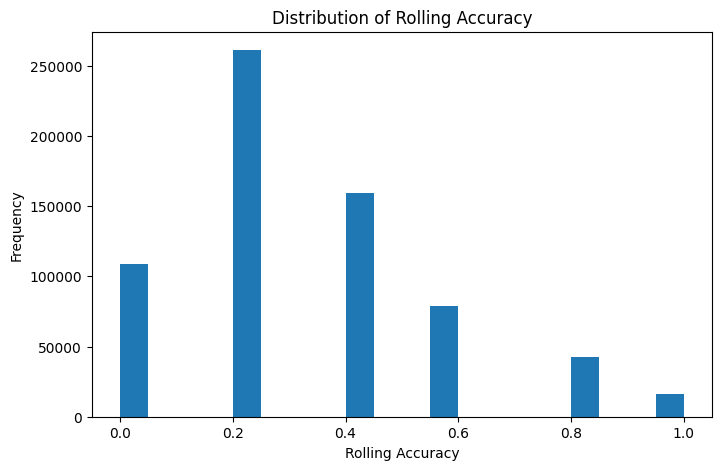

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    df["rolling_accuracy"].dropna(),
    bins=20
)

plt.xlabel("Rolling Accuracy")
plt.ylabel("Frequency")
plt.title("Distribution of Rolling Accuracy")

plt.show()

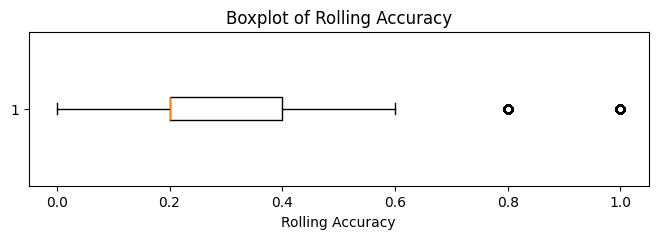

In [ ]:
plt.figure(figsize=(8,2))

plt.boxplot(
    df["rolling_accuracy"].dropna(),
    vert=False
)

plt.xlabel("Rolling Accuracy")
plt.title("Boxplot of Rolling Accuracy")

plt.show()

# Mastery Threshold Evaluation

## Objective

Evaluate multiple rolling accuracy thresholds to determine a suitable definition of mastery.

## Methodology

Several candidate thresholds are compared by examining the percentage of interactions classified as mastered.

The selected threshold should identify learners with strong recent performance while retaining a sufficient number of training examples.

## Expected Output

Class distributions for different mastery thresholds.

In [ ]:
candidate_thresholds = [0.40, 0.60, 0.80]

for threshold in candidate_thresholds:

    mastered = (df["rolling_accuracy"] >= threshold).astype(int)

    percentage = (
        mastered.value_counts(normalize=True)
        .sort_index() * 100
    )

    print("=" * 50)
    print(f"Rolling Accuracy Threshold: {threshold:.2f}")
    print(percentage.rename(index={0: "Not Mastered",
                                   1: "Mastered"}))

Rolling Accuracy Threshold: 0.40
rolling_accuracy
Not Mastered    68.453866
Mastered        31.546134
Name: proportion, dtype: float64
Rolling Accuracy Threshold: 0.60
rolling_accuracy
Not Mastered    85.387711
Mastered        14.612289
Name: proportion, dtype: float64
Rolling Accuracy Threshold: 0.80
rolling_accuracy
Not Mastered    93.771213
Mastered         6.228787
Name: proportion, dtype: float64


# 14. Mastery Detection and Validation

## Objective

Identify mastered interactions using the selected rolling accuracy threshold and verify the resulting labels.

## Methodology

Based on the threshold evaluation, a learner is considered to have mastered a skill when the rolling accuracy over the previous five interactions is at least **0.60**.

The generated mastery labels are validated by examining randomly selected student–skill sequences.

## Expected Output

- Binary mastery feature
- Mastery distribution
- Sample validation sequences

In [ ]:
# =====================================================
# Mastery Detection
# =====================================================

MASTERY_THRESHOLD = 0.60

df["mastered"] = (
    df["rolling_accuracy"] >= MASTERY_THRESHOLD
).astype(int)

print(f"Mastery Threshold : {MASTERY_THRESHOLD}")

Mastery Threshold : 0.6


In [ ]:
# =====================================================
# Mastery Distribution
# =====================================================

mastery_distribution = (
    df["mastered"]
      .value_counts()
      .sort_index()
      .rename(index={
          0: "Not Mastered",
          1: "Mastered"
      })
      .to_frame("Count")
)

mastery_distribution["Percentage"] = (
    mastery_distribution["Count"] /
    len(df) * 100
).round(2)

display(mastery_distribution)

,Count,Percentage
mastered,,
Not Mastered,805049,85.39
Mastered,137767,14.61


In [ ]:
# =====================================================
# Random Validation
# =====================================================

sample_pairs = (
    df[df["mastered"] == 1]
      [["studentId", "skill"]]
      .drop_duplicates()
      .sample(5, random_state=42)
)

for _, row in sample_pairs.iterrows():

    print("=" * 100)

    display(
        df[
            (df["studentId"] == row["studentId"]) &
            (df["skill"] == row["skill"])
        ][[
            "interaction_order",
            "correct",
            "rolling_accuracy",
            "mastered"
        ]]
    )

,interaction_order,correct,rolling_accuracy,mastered
454592,1,0,NaN,0
454593,2,0,NaN,0
454594,3,0,NaN,0
454595,4,0,NaN,0
454596,5,0,NaN,0
454597,6,0,0.0,0
454598,7,0,0.0,0
454599,8,0,0.0,0
454600,9,0,0.0,0
454601,10,0,0.0,0


,interaction_order,correct,rolling_accuracy,mastered
68226,1,1,NaN,0
68227,2,0,NaN,0
68228,3,1,NaN,0
68229,4,1,NaN,0
68230,5,0,NaN,0
68231,6,0,0.6,1
68232,7,0,0.4,0
68233,8,0,0.4,0
68234,9,0,0.2,0
68235,10,0,0.0,0


,interaction_order,correct,rolling_accuracy,mastered
825092,1,1,NaN,0
825093,2,1,NaN,0
825094,3,0,NaN,0
825095,4,1,NaN,0
825096,5,1,NaN,0
825097,6,0,0.8,1
825098,7,0,0.6,1
825099,8,0,0.4,0
825100,9,0,0.4,0
825101,10,1,0.2,0


,interaction_order,correct,rolling_accuracy,mastered
406765,1,0,NaN,0
406766,2,0,NaN,0
406767,3,0,NaN,0
406768,4,0,NaN,0
406769,5,0,NaN,0
...,...,...,...,...
406866,102,1,0.6,1
406867,103,0,0.6,1
406868,104,1,0.4,0
406869,105,1,0.6,1


,interaction_order,correct,rolling_accuracy,mastered
690129,1,0,NaN,0
690130,2,1,NaN,0
690131,3,0,NaN,0
690132,4,0,NaN,0
690133,5,0,NaN,0
690134,6,1,0.2,0
690135,7,1,0.4,0
690136,8,1,0.4,0
690137,9,0,0.6,1
690138,10,0,0.6,1


# 15. Future Accuracy Construction

## Objective

Estimate future learning performance for each interaction.

## Methodology

Future accuracy is calculated as the average correctness over all future interactions of the same student–skill sequence.

Only interactions occurring after the current interaction are considered.

This feature is later combined with mastery information to identify forgetting events.

## Expected Output

A continuous feature named `future_accuracy`.

In [ ]:
# =====================================================
# Future Accuracy Construction
# =====================================================

df["future_accuracy"] = (
    df.groupby(["studentId", "skill"])["correct"]
      .transform(
          lambda x: (
              x.iloc[::-1]
               .shift(1)
               .expanding()
               .mean()
               .iloc[::-1]
          )
      )
)

display(
    df[[
        "correct",
        "future_accuracy"
    ]].head(15)
)

,correct,future_accuracy
0,1,0.789474
1,1,0.777778
2,1,0.764706
3,1,0.750000
4,0,0.800000
5,1,0.785714
6,1,0.769231
7,1,0.750000
8,1,0.727273
9,1,0.700000


In [ ]:
df["future_accuracy"].describe()

,future_accuracy
count,871614.000000
mean,0.451116
std,0.258870
min,0.000000
25%,0.266667
50%,0.375000
75%,0.567568
max,1.000000


In [ ]:
display(
    df[[
        "interaction_order",
        "correct",
        "future_accuracy"
    ]].head(20)
)

,interaction_order,correct,future_accuracy
0,1,1,0.789474
1,2,1,0.777778
2,3,1,0.764706
3,4,1,0.750000
4,5,0,0.800000
5,6,1,0.785714
6,7,1,0.769231
7,8,1,0.750000
8,9,1,0.727273
9,10,1,0.700000


In [ ]:
# =====================================================
# Remove Rows Without Future Information
# =====================================================

initial_rows = len(df)

df = df.dropna(subset=["future_accuracy"]).reset_index(drop=True)

print(f"Rows before : {initial_rows:,}")
print(f"Rows after  : {len(df):,}")
print(f"Rows removed: {initial_rows - len(df):,}")

Rows before : 942,816
Rows after  : 871,614
Rows removed: 71,202


# 16. Forget Event Construction

## Objective

Construct the final target variable representing knowledge decay.

## Methodology

A forgetting event is identified only when the learner has previously demonstrated mastery of a skill but their future performance falls below the selected mastery threshold.

The target is defined as follows:

- Forget Event (1): Mastered = 1 and Future Accuracy < 0.60
- No Forget Event (0): Otherwise

This definition ensures that forgetting is measured only after sufficient evidence of learning has been observed.

## Expected Output

A binary target variable named `forget_event`.

In [ ]:
# =====================================================
# Forget Event Construction
# =====================================================

FORGET_THRESHOLD = 0.60

df["forget_event"] = (
    (df["mastered"] == 1) &
    (df["future_accuracy"] < FORGET_THRESHOLD)
).astype(int)

print("Forget Threshold :", FORGET_THRESHOLD)

Forget Threshold : 0.6


# 17. Forget Event Distribution

## Objective

Analyze the class distribution of the constructed target variable.

## Methodology

The frequency and percentage of forgetting and non-forgetting events are calculated.

This analysis helps identify any class imbalance before model development.

## Expected Output

Distribution of the `forget_event` target.

In [ ]:
# =====================================================
# Forget Event Distribution
# =====================================================

forget_distribution = (
    df["forget_event"]
      .value_counts()
      .sort_index()
      .rename({
          0: "No Forget Event",
          1: "Forget Event"
      })
      .to_frame("Count")
)

forget_distribution["Percentage"] = (
    forget_distribution["Count"] /
    len(df) * 100
).round(2)

display(forget_distribution)

,Count,Percentage
forget_event,,
No Forget Event,791900,90.85
Forget Event,79714,9.15


# 18. Forget Event Validation

## Objective

Validate the generated forgetting labels.

## Methodology

Random student–skill sequences are inspected to verify that forgetting events occur only after mastery has been achieved and future performance subsequently decreases.

## Expected Output

Sample interaction sequences showing mastery, future accuracy and forgetting labels.

In [ ]:
# =====================================================
# Forget Event Validation
# =====================================================

sample_pairs = (
    df[df["forget_event"] == 1]
      [["studentId", "skill"]]
      .drop_duplicates()
      .sample(5, random_state=42)
)

for _, row in sample_pairs.iterrows():

    print("=" * 100)

    display(
        df[
            (df["studentId"] == row["studentId"]) &
            (df["skill"] == row["skill"])
        ][[
            "interaction_order",
            "correct",
            "rolling_accuracy",
            "mastered",
            "future_accuracy",
            "forget_event"
        ]]
    )

,interaction_order,correct,rolling_accuracy,mastered,future_accuracy,forget_event
294852,1,0,NaN,0,0.555556,0
294853,2,0,NaN,0,0.625000,0
294854,3,0,NaN,0,0.714286,0
294855,4,0,NaN,0,0.833333,0
294856,5,1,NaN,0,0.800000,0
294857,6,1,0.2,0,0.750000,0
294858,7,1,0.4,0,0.666667,0
294859,8,1,0.6,1,0.500000,1
294860,9,0,0.8,1,1.000000,0


,interaction_order,correct,rolling_accuracy,mastered,future_accuracy,forget_event
630325,1,0,NaN,0,0.500000,0
630326,2,1,NaN,0,0.428571,0
630327,3,1,NaN,0,0.333333,0
630328,4,1,NaN,0,0.200000,0
630329,5,0,NaN,0,0.250000,0
630330,6,0,0.6,1,0.333333,1
630331,7,0,0.6,1,0.500000,1
630332,8,0,0.4,0,1.000000,0


,interaction_order,correct,rolling_accuracy,mastered,future_accuracy,forget_event
278683,1,0,NaN,0,0.285714,0
278684,2,0,NaN,0,0.307692,0
278685,3,0,NaN,0,0.333333,0
278686,4,0,NaN,0,0.363636,0
278687,5,0,NaN,0,0.400000,0
278688,6,1,0.0,0,0.333333,0
278689,7,1,0.2,0,0.250000,0
278690,8,1,0.4,0,0.142857,0
278691,9,0,0.6,1,0.166667,1
278692,10,0,0.6,1,0.200000,1


,interaction_order,correct,rolling_accuracy,mastered,future_accuracy,forget_event
24307,1,0,NaN,0,0.400000,0
24308,2,1,NaN,0,0.333333,0
24309,3,1,NaN,0,0.250000,0
24310,4,1,NaN,0,0.142857,0
24311,5,0,NaN,0,0.166667,0
24312,6,0,0.6,1,0.200000,1
24313,7,0,0.6,1,0.250000,1
24314,8,0,0.4,0,0.333333,0
24315,9,0,0.2,0,0.500000,0
24316,10,0,0.0,0,1.000000,0


,interaction_order,correct,rolling_accuracy,mastered,future_accuracy,forget_event
362425,1,0,NaN,0,0.416667,0
362426,2,1,NaN,0,0.391304,0
362427,3,0,NaN,0,0.409091,0
362428,4,0,NaN,0,0.428571,0
362429,5,0,NaN,0,0.450000,0
362430,6,0,0.2,0,0.473684,0
362431,7,0,0.2,0,0.500000,0
362432,8,1,0.0,0,0.470588,0
362433,9,0,0.2,0,0.500000,0
362434,10,0,0.2,0,0.533333,0


# 19. Final Dataset Verification

## Objective

Verify that the processed dataset is complete, consistent and ready for machine learning.

## Methodology

The final dataset is validated using the following quality checks:

- Dataset shape
- Missing values
- Data types
- Target distribution
- Range validation for engineered features

These checks ensure that no invalid records remain before model development.

## Expected Output

A clean and model-ready dataset.

In [ ]:
# =====================================================
# Final Dataset Overview
# =====================================================

print("=" * 60)
print("Final Dataset Shape")
print("=" * 60)

print(df.shape)

print()

print("=" * 60)
print("Total Features")
print("=" * 60)

print(len(df.columns))

Final Dataset Shape
(871614, 85)

Total Features
85


In [ ]:
# =====================================================
# Missing Value Verification
# =====================================================

missing = df.isnull().sum()

missing = missing[missing > 0]

if len(missing) == 0:
    print("✅ No missing values found.")
else:
    display(missing)

,0
rolling_accuracy,243910


In [ ]:
# =====================================================
# Binary Target Validation
# =====================================================

print("Forget Event Values")
print(sorted(df["forget_event"].unique()))

print()

print("Mastered Values")
print(sorted(df["mastered"].unique()))

Forget Event Values
[np.int64(0), np.int64(1)]

Mastered Values
[np.int64(0), np.int64(1)]


In [ ]:
# =====================================================
# Feature Range Validation
# =====================================================

print("Rolling Accuracy")

print(
    "Min :",
    df["rolling_accuracy"].min()
)

print(
    "Max :",
    df["rolling_accuracy"].max()
)

print()

print("Future Accuracy")

print(
    "Min :",
    df["future_accuracy"].min()
)

print(
    "Max :",
    df["future_accuracy"].max()
)

Rolling Accuracy
Min : 0.0
Max : 1.0

Future Accuracy
Min : 0.0
Max : 1.0


In [ ]:
# =====================================================
# Final Target Distribution
# =====================================================

distribution = (
    df["forget_event"]
      .value_counts(normalize=True)
      .mul(100)
      .round(2)
)

display(distribution)

,proportion
forget_event,
0,90.85
1,9.15


# 20. Save Model-Ready Dataset

## Objective

Save the final processed dataset for model development.

## Methodology

The verified dataset is stored in the Processed directory so that subsequent notebooks use the same input without repeating preprocessing.

## Expected Output

A model-ready dataset saved as:

`model_ready_dataset.csv`

In [ ]:
# =====================================================
# Save Model-Ready Dataset
# =====================================================

output_path = DATA_DIR / "Processed" / "model_ready_dataset.csv"

df.to_csv(
    output_path,
    index=False
)

print("✅ Dataset saved successfully.")
print(output_path)

✅ Dataset saved successfully.
/content/drive/MyDrive/Personal Knowledge Decay Predictor/Data/Processed/model_ready_dataset.csv


# Notebook Summary

This notebook transformed the cleaned interaction dataset into a model-ready dataset for knowledge decay prediction.

The following tasks were completed:

- Chronological ordering of student–skill interactions
- Construction of historical learning features
- Rolling accuracy computation
- Mastery detection
- Future accuracy estimation
- Forget event target generation
- Dataset verification
- Export of the final processed dataset

The resulting dataset will be used in Notebook 05 for machine learning model development.